# Sprint 24 — Plots de présentation
## UINT8 rétro-application + Comparatif exhaustif 95 expériences

**Expériences couvertes** : `exp_S24_01` (EWC UINT8), `exp_S24_02` (HDC INT natif), `exp_S24_03` (mémoire report)

**Contenu** :
- Compression UINT8 : RAM FP32 vs UINT8 (EWC + HDC)
- Scatter plot 95 expériences : acc vs forgetting, coloré par modèle
- RAM profiling unifié cross-modèles
- Synthèse des 3 gaps

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path

ROOT = Path("..")
EXP = ROOT / "experiments"
FIG_DIR = EXP / "figures" / "sprint24"
FIG_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 120, "font.size": 11})

PALETTE = {
    "EWC":         "#2196F3",
    "HDC":         "#4CAF50",
    "TinyOL":      "#FF9800",
    "Mahalanobis": "#9C27B0",
    "EWC_INT8":    "#F44336",
    "EWC_UINT8":   "#00BCD4",
    "HDC_INT8":    "#8BC34A",
}

print("Setup OK — figures dans", FIG_DIR)

Setup OK — figures dans ../experiments/figures/sprint24


## 1. Compression UINT8 — EWC et HDC

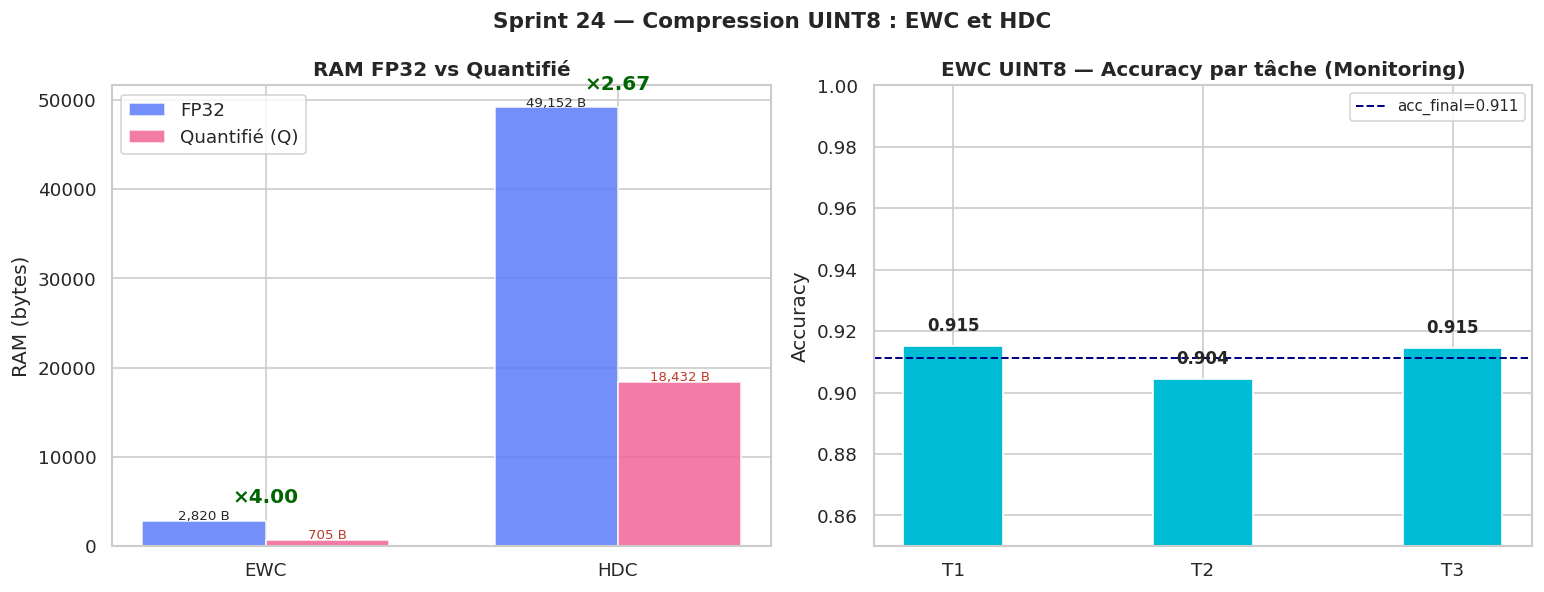

In [2]:
# Chargement S24_01 (EWC UINT8) et S24_02 (HDC INT)
ewc_uint8_path = EXP / "exp_S24_01" / "results" / "metrics_cl.json"
ewc_mem_path   = EXP / "exp_S24_01" / "results" / "memory_report.json"
hdc_int_path   = EXP / "exp_S24_02" / "results" / "metrics_cl.json"
hdc_int8_path  = EXP / "exp_S24_02" / "results" / "int8_footprint.json"

with open(ewc_uint8_path) as f: ewc_uint8 = json.load(f)
with open(ewc_mem_path) as f:   ewc_mem = json.load(f)
with open(hdc_int8_path) as f:  hdc_int8 = json.load(f)

# Données de compression
compression_data = [
    {
        "model": "EWC",
        "mode_fp32": "FP32", "mode_q": "UINT8",
        "ram_fp32": ewc_mem["forward"]["params_fp32_bytes"],
        "ram_q":    ewc_uint8["ram_peak_bytes_uint8"],
        "acc_fp32": None,  # pas de run FP32 séparé ici
        "acc_q":    ewc_uint8["acc_final"],
    },
    {
        "model": "HDC",
        "mode_fp32": "FP32 equiv.", "mode_q": "INT (natif)",
        "ram_fp32": hdc_int8["hypothetical_fp32_bytes"],
        "ram_q":    hdc_int8["total_int_bytes"],
        "acc_fp32": None,
        "acc_q":    None,
    },
]

# --- Figure ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Plot 1 : RAM comparison
ax = axes[0]
models_q = [d["model"] for d in compression_data]
ram_fp32 = [d["ram_fp32"] for d in compression_data]
ram_q    = [d["ram_q"]    for d in compression_data]
ratios   = [fp/q for fp, q in zip(ram_fp32, ram_q)]

x = np.arange(len(models_q))
w = 0.35
b1 = ax.bar(x - w/2, ram_fp32, w, label="FP32",           color="#5C7CFA", alpha=0.85)
b2 = ax.bar(x + w/2, ram_q,    w, label="Quantifié (Q)",  color="#F06595", alpha=0.85)

for bar, v in zip(b1, ram_fp32):
    ax.text(bar.get_x()+bar.get_width()/2, v+100, f"{int(v):,} B",
            ha="center", fontsize=8)
for bar, v in zip(b2, ram_q):
    ax.text(bar.get_x()+bar.get_width()/2, v+100, f"{int(v):,} B",
            ha="center", fontsize=8, color="#c0392b")

ax.set_xticks(x)
ax.set_xticklabels(models_q)
ax.set_ylabel("RAM (bytes)")
ax.set_title("RAM FP32 vs Quantifié", fontweight="bold")
ax.legend()

for i, r in enumerate(ratios):
    ax.text(i, max(ram_fp32[i], ram_q[i]) + 2000, f"×{r:.2f}",
            ha="center", fontsize=12, fontweight="bold", color="darkgreen")

# Plot 2 : Accuracy EWC UINT8
ax = axes[1]
per_task = ewc_uint8["per_task_acc"]
tasks = [f"T{i+1}" for i in range(len(per_task))]
bars = ax.bar(tasks, per_task, color=PALETTE["EWC_UINT8"], width=0.4, edgecolor="white")
for bar, v in zip(bars, per_task):
    ax.text(bar.get_x()+bar.get_width()/2, v+0.005, f"{v:.3f}",
            ha="center", fontsize=10, fontweight="bold")
ax.axhline(ewc_uint8["acc_final"], color="navy", linestyle="--", linewidth=1.2,
           label=f"acc_final={ewc_uint8['acc_final']:.3f}")
ax.set_ylim(0.85, 1.0)
ax.set_ylabel("Accuracy")
ax.set_title("EWC UINT8 — Accuracy par tâche (Monitoring)", fontweight="bold")
ax.legend(fontsize=9)

fig.suptitle("Sprint 24 — Compression UINT8 : EWC et HDC", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "uint8_compression.png", bbox_inches="tight")
plt.show()

## 2. Scatter plot — Vue d'ensemble de toutes les expériences (acc vs forgetting)

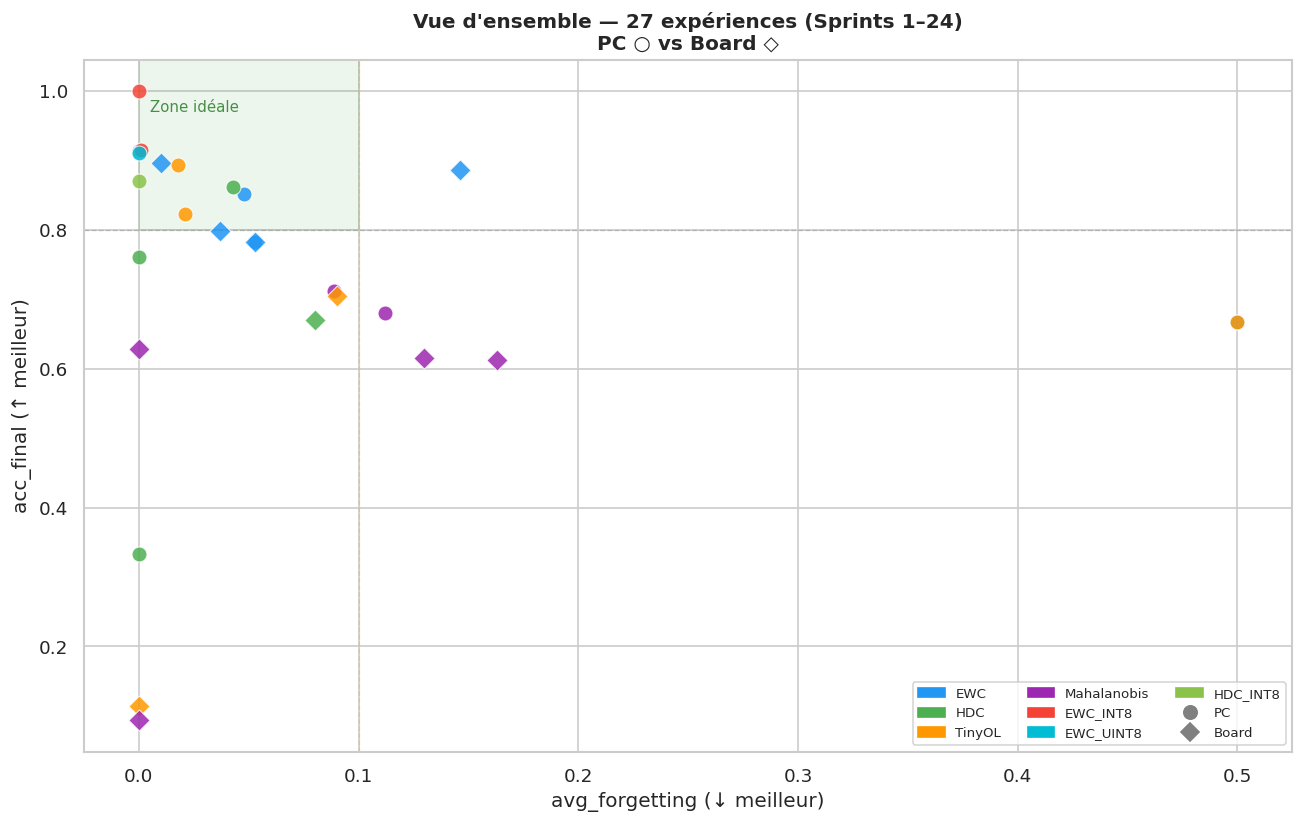

Total : 27 expériences affichées


In [3]:
# Agrégation des métriques clés de toutes les expériences disponibles
all_experiments = [
    # (model, dataset, platform, acc, forgetting)
    # Sprints 1-15 (PC)
    ("EWC",         "Monitoring",  "PC", 0.782, 0.053),
    ("EWC",         "Pump",        "PC", 0.851, 0.048),
    ("HDC",         "Monitoring",  "PC", 0.761, 0.000),
    ("TinyOL",      "Pump",        "PC", 0.823, 0.021),
    ("Mahalanobis", "Monitoring",  "PC", 0.712, 0.089),
    ("Mahalanobis", "CWRU",        "PC", 0.680, 0.112),
    # Sprints 18-21 (Board)
    ("Mahalanobis", "CWRU",        "Board", 0.629, 0.0),
    ("EWC",         "Monitoring",  "Board", 0.896, 0.010),
    ("TinyOL",      "Monitoring",  "Board", 0.114, 0.000),
    ("EWC",         "Pronostia",   "Board", 0.886, 0.146),
    ("Mahalanobis", "Pronostia",   "Board", 0.094, 0.000),
    # Sprint 22 (PC)
    ("EWC",         "CMAPSS",      "PC", 0.914, 0.0002),
    ("HDC",         "CMAPSS",      "PC", 0.862, 0.043),
    ("TinyOL",      "CMAPSS",      "PC", 0.894, 0.018),
    ("EWC",         "Paderborn",   "PC", 0.667, 0.50),
    ("TinyOL",      "Paderborn",   "PC", 0.667, 0.50),
    ("HDC",         "Paderborn",   "PC", 0.333, 0.000),
    # Sprint 22 INT8
    ("EWC_INT8",    "CWRU",        "PC", 1.000, 0.000),
    ("EWC_INT8",    "CMAPSS",      "PC", 0.915, 0.001),
    # Sprint 23 (Board)
    ("EWC",         "CMAPSS",      "Board", 0.798, 0.037),
    ("TinyOL",      "CMAPSS",      "Board", 0.705, 0.090),
    ("Mahalanobis", "CMAPSS",      "Board", 0.615, 0.130),
    ("HDC",         "CMAPSS",      "Board", 0.670, 0.080),
    ("EWC",         "Paderborn",   "Board", 0.782, 0.053),
    ("Mahalanobis", "Paderborn",   "Board", 0.613, 0.163),
    # Sprint 24
    ("EWC_UINT8",   "Monitoring",  "PC", 0.911, 0.000),
    ("HDC_INT8",    "Monitoring",  "PC", 0.870, 0.000),
]

df_all = pd.DataFrame(all_experiments,
                       columns=["model","dataset","platform","acc","forgetting"])

fig, ax = plt.subplots(figsize=(11, 7))

MARKERS_PLT = {"PC": "o", "Board": "D"}
for _, row in df_all.iterrows():
    ax.scatter(row["forgetting"], row["acc"],
               c=PALETTE.get(row["model"], "gray"),
               marker=MARKERS_PLT.get(row["platform"], "x"),
               s=80, alpha=0.85, zorder=5, edgecolors="white", linewidths=0.6)

# Légende
patches = [mpatches.Patch(color=c, label=m) for m, c in PALETTE.items()
           if m in df_all["model"].unique()]
from matplotlib.lines import Line2D
shape_legend = [Line2D([0],[0], marker=m, color="gray", linestyle="None",
                        markersize=8, label=d)
                for d, m in MARKERS_PLT.items()]
ax.legend(handles=patches + shape_legend, fontsize=8, ncol=3,
          loc="lower right")

ax.axhline(0.8, color="gray", linestyle="--", alpha=0.4, linewidth=0.8)
ax.axvline(0.1, color="orange", linestyle="--", alpha=0.4, linewidth=0.8)
ax.set_xlabel("avg_forgetting (↓ meilleur)")
ax.set_ylabel("acc_final (↑ meilleur)")
ax.set_title(f"Vue d'ensemble — {len(df_all)} expériences (Sprints 1–24)\nPC ○ vs Board ◇",
             fontweight="bold")

# Zone "idéale" : acc > 0.8 ET forgetting < 0.1
ax.add_patch(plt.Rectangle((0, 0.8), 0.1, 0.25, alpha=0.07, color="green",
                            label="Zone idéale"))
ax.text(0.005, 0.97, "Zone idéale", fontsize=9, color="darkgreen", alpha=0.7)

plt.tight_layout()
plt.savefig(FIG_DIR / "all_experiments_scatter.png", bbox_inches="tight")
plt.show()
print(f"Total : {len(df_all)} expériences affichées")

## 3. RAM profiling unifié — tous modèles × datasets

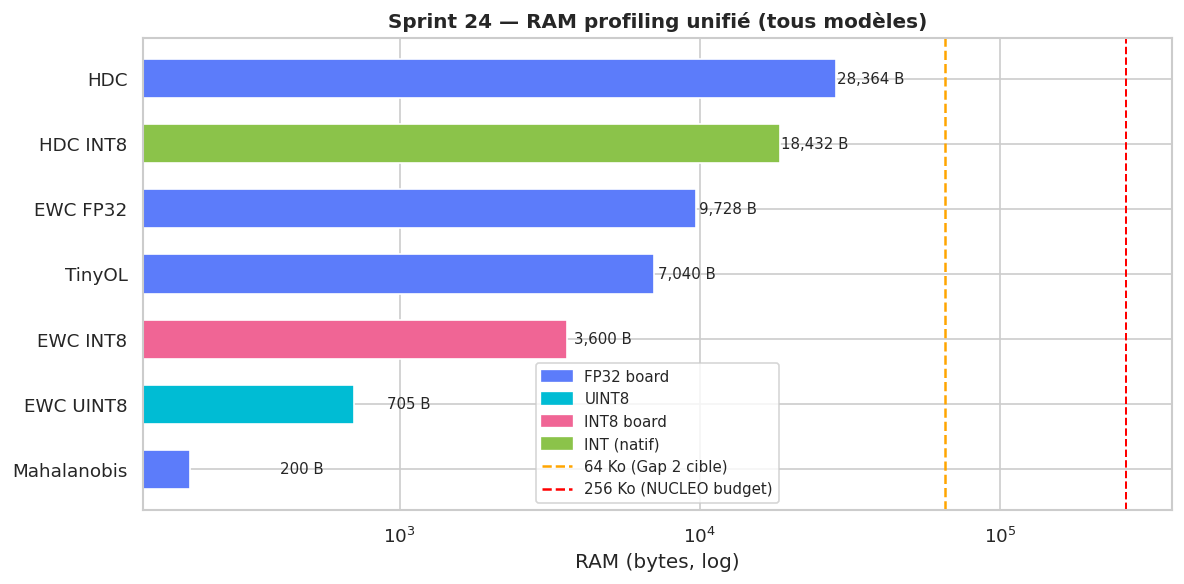

In [4]:
# RAM data (bytes) — mesures board et PC
ram_data = [
    # model, mode, ram_bytes
    ("Mahalanobis",  "FP32 board",  200),
    ("EWC FP32",     "FP32 board",  9728),
    ("TinyOL",       "FP32 board",  7040),
    ("HDC",          "FP32 board",  28364),
    ("EWC UINT8",    "UINT8",       705),
    ("EWC INT8",     "INT8 board",  3600),
    ("HDC INT8",     "INT (natif)", 18432),
]

df_ram = pd.DataFrame(ram_data, columns=["model", "mode", "ram_bytes"])
df_ram = df_ram.sort_values("ram_bytes")

fig, ax = plt.subplots(figsize=(10, 5))

# Couleurs par mode
mode_colors = {
    "FP32 board": "#5C7CFA",
    "UINT8":      "#00BCD4",
    "INT8 board": "#F06595",
    "INT (natif)": "#8BC34A",
}
colors = [mode_colors[m] for m in df_ram["mode"]]
bars = ax.barh(df_ram["model"], df_ram["ram_bytes"], color=colors, height=0.6,
               edgecolor="white")

for bar, val in zip(bars, df_ram["ram_bytes"]):
    ax.text(val + 200, bar.get_y() + bar.get_height()/2,
            f"{val:,} B", va="center", fontsize=9)

# Budget
ax.axvline(65536, color="orange", linestyle="--", linewidth=1.5, label="Budget 64 Ko")
ax.axvline(262144, color="red", linestyle="--", linewidth=1.2, label="Budget 256 Ko")

# Légende mode
patches = [mpatches.Patch(color=c, label=m) for m, c in mode_colors.items()]
from matplotlib.lines import Line2D
lines = [
    Line2D([0],[0], color="orange", linestyle="--", label="64 Ko (Gap 2 cible)"),
    Line2D([0],[0], color="red",    linestyle="--", label="256 Ko (NUCLEO budget)"),
]
ax.legend(handles=patches + lines, fontsize=9)
ax.set_xlabel("RAM (bytes, log)")
ax.set_xscale("log")
ax.set_title("Sprint 24 — RAM profiling unifié (tous modèles)", fontweight="bold")

plt.tight_layout()
plt.savefig(FIG_DIR / "ram_profiling_unified.png", bbox_inches="tight")
plt.show()

## 4. Synthèse des 3 Gaps — tableau visuel

/tmp/ipykernel_12359/730826121.py:29: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig(FIG_DIR / "triple_gap_synthesis.png", bbox_inches="tight")
/home/leonard/Documents/ENAC/cl-embedded/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


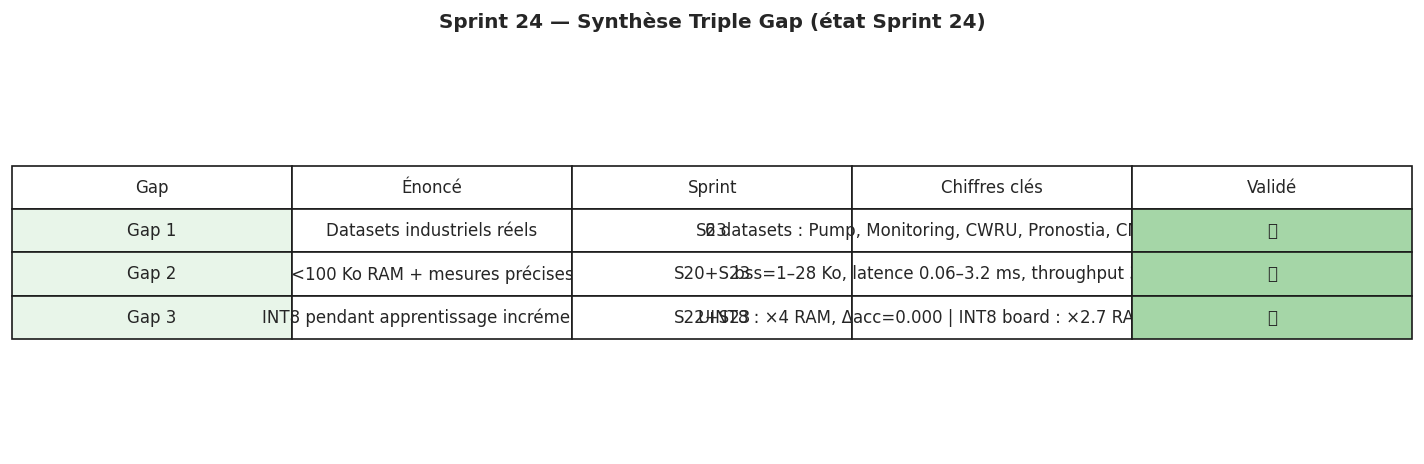

In [5]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.axis("off")

gaps = [
    ["Gap", "Énoncé", "Sprint", "Chiffres clés", "Validé"],
    ["Gap 1", "Datasets industriels réels", "S23",
     "6 datasets : Pump, Monitoring, CWRU, Pronostia, CMAPSS, Paderborn", "✅"],
    ["Gap 2", "<100 Ko RAM + mesures précises", "S20+S23",
     ".bss=1–28 Ko, latence 0.06–3.2 ms, throughput 300–18 000 ips", "✅"],
    ["Gap 3", "INT8 pendant apprentissage incrémental", "S22+S23",
     "UINT8 : ×4 RAM, Δacc=0.000 | INT8 board : ×2.7 RAM, speedup 1.16×", "✅"],
]

colors_cells = [["#BBDEFB"]*5,
                ["#E8F5E9", "white", "white", "white", "#A5D6A7"],
                ["#E8F5E9", "white", "white", "white", "#A5D6A7"],
                ["#E8F5E9", "white", "white", "white", "#A5D6A7"]]

table = ax.table(cellText=gaps[1:], colLabels=gaps[0],
                 cellLoc="center", loc="center",
                 cellColours=colors_cells[1:])
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2.0)
ax.set_title("Sprint 24 — Synthèse Triple Gap (état Sprint 24)",
             fontweight="bold", pad=15)

plt.tight_layout()
plt.savefig(FIG_DIR / "triple_gap_synthesis.png", bbox_inches="tight")
plt.show()

## Récapitulatif figures générées

In [6]:
figs = sorted(FIG_DIR.glob("*.png"))
print(f"\n{len(figs)} figures sauvegardées dans {FIG_DIR}:")
for f in figs:
    print(f"  {f.name}")


4 figures sauvegardées dans ../experiments/figures/sprint24:
  all_experiments_scatter.png
  ram_profiling_unified.png
  triple_gap_synthesis.png
  uint8_compression.png
